## Train_Data

In [ ]:
# STEP 1: IMPORT LIBRARIES

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
# STEP 2: LOAD DATASET
data = pd.read_csv(r"C:\Users\Chekk\OneDrive\Desktop\Major_Project\Machine_Learning_Project\train_FD001.txt",sep=" ",header=None)

# Remove extra columns
data.drop(columns=[26, 27], inplace=True)

# Assign column names
columns = [
    'unit_number','time_in_cycles','setting_1','setting_2','TRA','T2','T24','T30','T50',
    'P2','P15','P30','Nf','Nc','epr','Ps30','phi','NRf','NRc','BPR','farB',
    'htBleed','Nf_dmd','PCNfR_dmd','W31','W32'
]

data.columns = columns

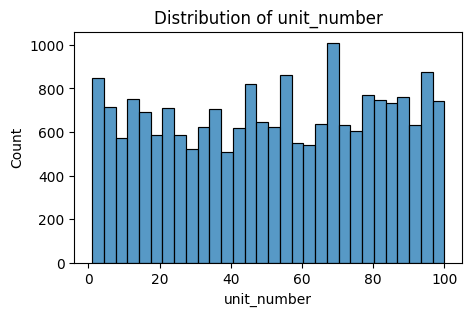

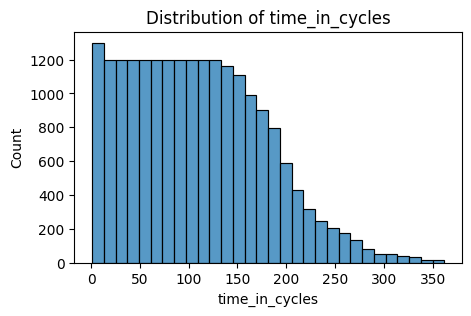

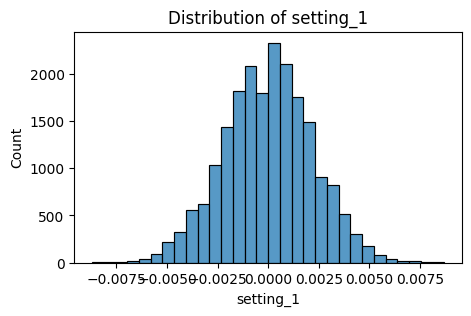

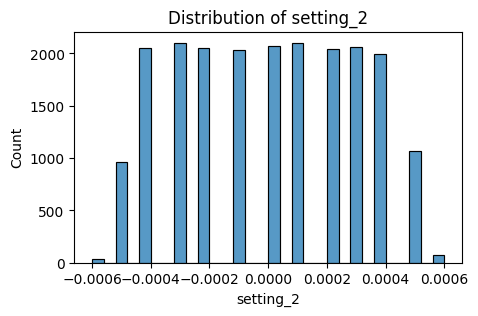

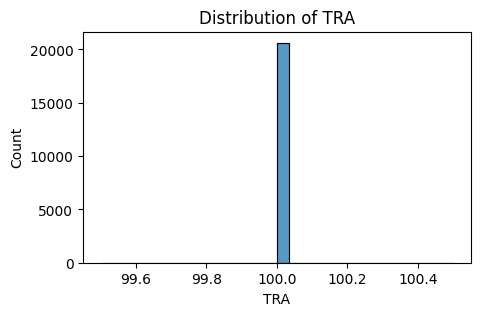

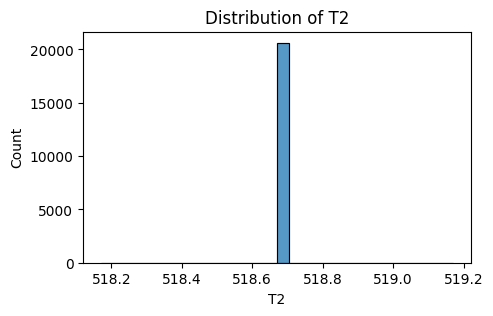

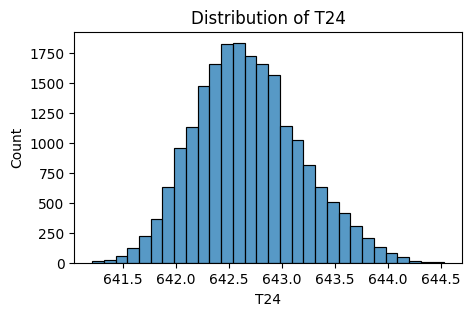

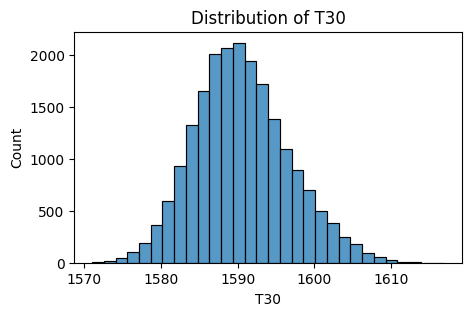

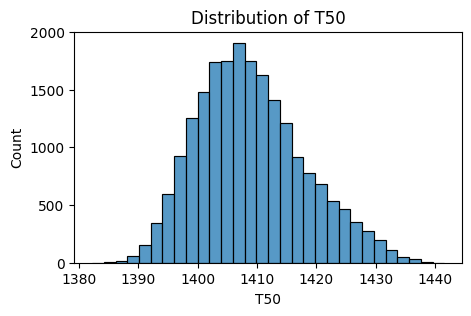

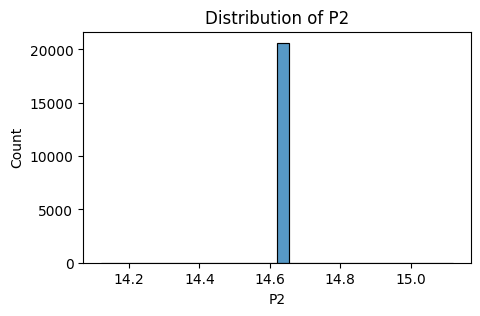

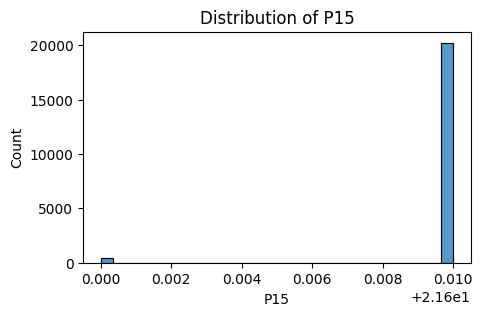

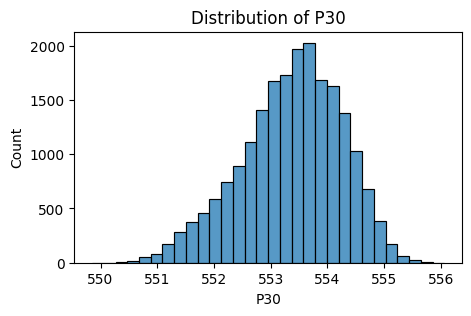

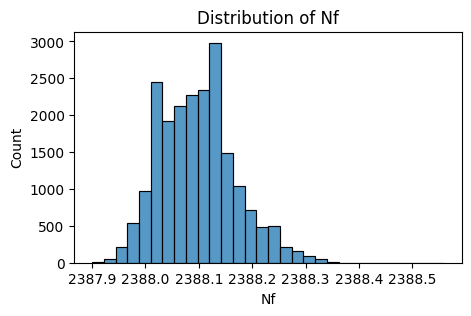

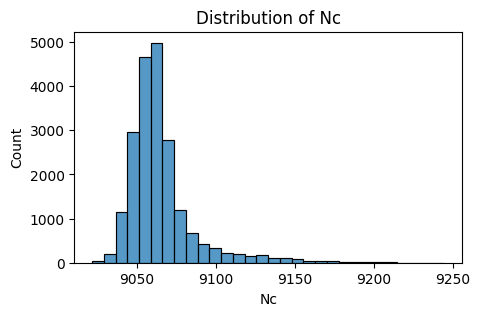

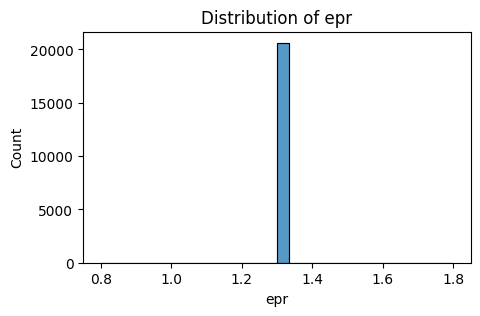

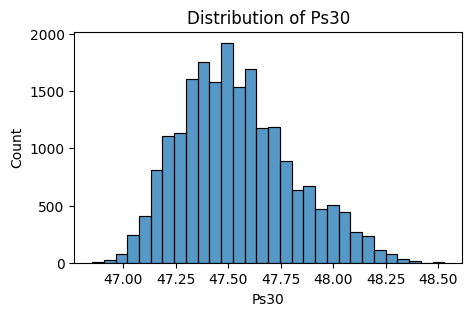

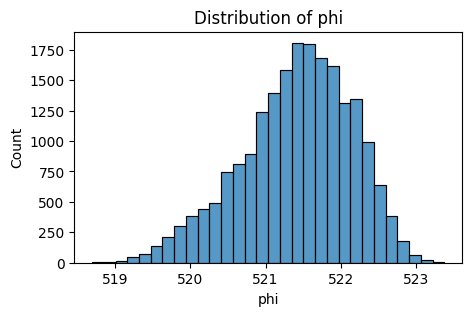

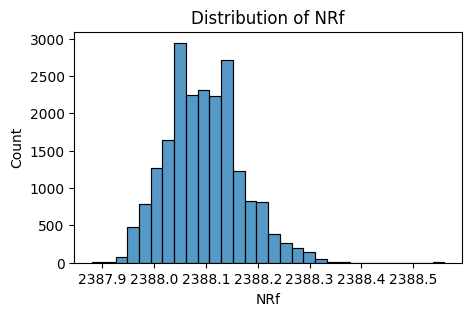

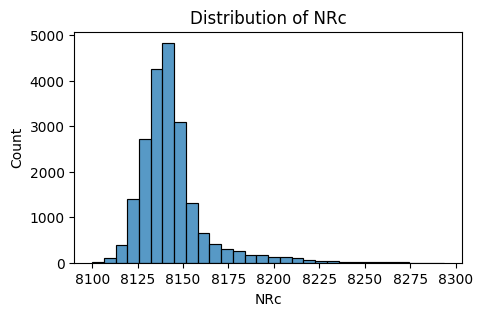

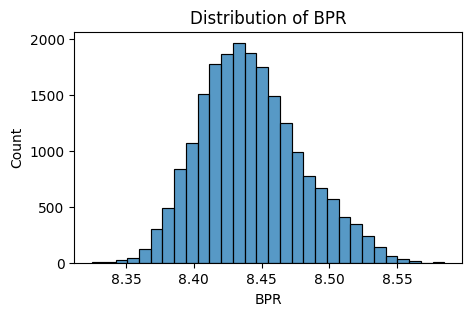

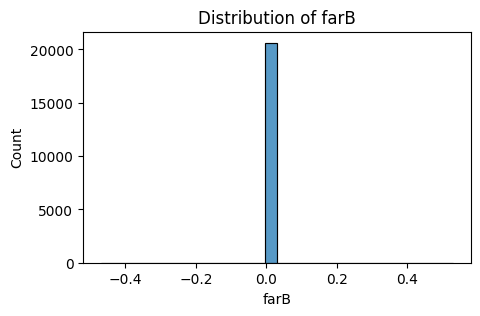

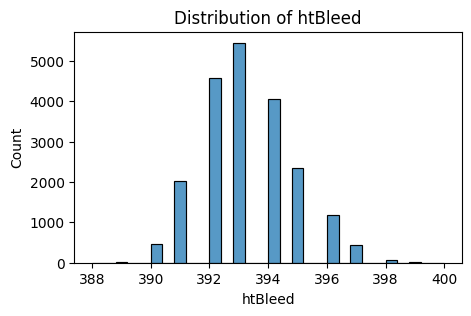

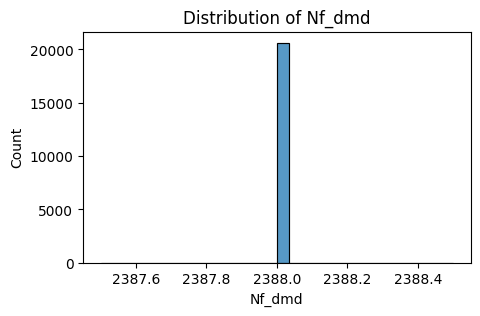

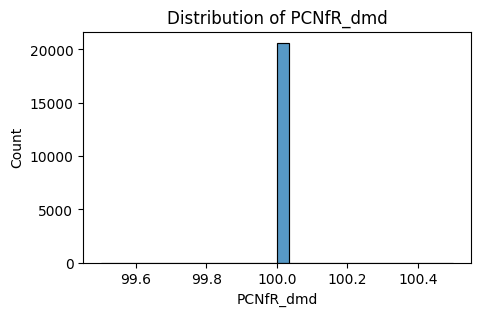

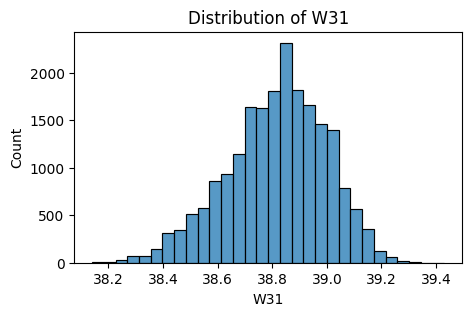

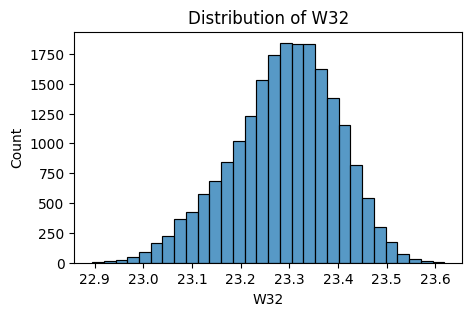

In [33]:
# STEP 3: EDA - HISTOGRAMS
# Understand distribution of each sensor

for col in data.columns:
    plt.figure(figsize=(5,3))
    sns.histplot(data[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()

In [34]:
# STEP 4: DATA PREPROCESSING
# Handle missing values
data = data.ffill()

# Drop unnecessary features
data.drop(columns=[
    'Nf_dmd','PCNfR_dmd','P2','T2','TRA','farB','epr'], inplace=True)



In [35]:
# STEP 5: NORMALIZATION
sensor_data = data.drop(columns=['unit_number','time_in_cycles'])

scaler = MinMaxScaler()
sensor_scaled = scaler.fit_transform(sensor_data)

sensor_scaled = pd.DataFrame(sensor_scaled, columns=sensor_data.columns)



In [36]:
# STEP 6: SEQUENCE CREATION
def create_sequences(data, seq_length):
    sequences = []
    for i in range(len(data) - seq_length):
        sequences.append(data.iloc[i:i+seq_length].values)
    return np.array(sequences)

sequence_length = 30
X_sequences = create_sequences(sensor_scaled, sequence_length)

print("Shape:", X_sequences.shape)

Shape: (20601, 30, 17)


In [37]:
# STEP 7: TIME-SERIES SPLIT
split = int(0.8 * len(X_sequences))

X_train = X_sequences[:split]
X_test = X_sequences[split:]

In [ ]:
# STEP 8: MODEL BUILDING
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.optimizers import Adam
timesteps = X_train.shape[1]
features = X_train.shape[2]

input_layer = Input(shape=(timesteps, features))

# Encoder
encoded = LSTM(64, activation='relu', return_sequences=False)(input_layer)

# Latent space
latent = RepeatVector(timesteps)(encoded)

# Decoder
decoded = LSTM(64, activation='relu', return_sequences=True)(latent)

# Output
output_layer = TimeDistributed(Dense(features))(decoded)

model = Model(inputs=input_layer, outputs=output_layer)

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 30, 17)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        20,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 30, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 30, 17)         │         1,105 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,121 (215.32 KB)

 Trainable params: 55,121 (215.32 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
# STEP 9: TRAIN MODEL
history = model.fit(X_train, X_train, epochs=5, batch_size=64, validation_data=(X_test, X_test),shuffle=False)

Epoch 1/5
258/258 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - loss: 0.0269 - val_loss: 0.0135
Epoch 2/5
258/258 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.0134 - val_loss: 0.0124
Epoch 3/5
258/258 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 0.0126 - val_loss: 0.0117
Epoch 4/5
258/258 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 0.0123 - val_loss: 0.0124
Epoch 5/5
258/258 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 0.0128 - val_loss: 0.0127


In [40]:
# STEP 10: RECONSTRUCTION ERROR
X_pred = model.predict(X_test)

reconstruction_error = np.mean(np.power(X_test - X_pred, 2),axis=(1,2))

129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step


In [41]:
# STEP 11: HEALTH INDEX
from sklearn.preprocessing import MinMaxScaler
error_min = reconstruction_error.min()
error_max = reconstruction_error.max()

health_index = 1 - ((reconstruction_error - error_min) / (error_max - error_min))

health_index = np.clip(health_index, 0, 1)

health_index_smooth = pd.Series(health_index).rolling(window=10, min_periods=1).mean()

In [42]:
# STEP 12: ADD HEALTH INDEX TO DATA
test_start = split + sequence_length

data["Health_Index"] = np.nan
data.loc[test_start:test_start + len(health_index) - 1, "Health_Index"] = health_index

data["Health_Index_Smoothed"] = np.nan
data.loc[test_start:test_start + len(health_index_smooth) - 1, "Health_Index_Smoothed"] = health_index_smooth.values



In [43]:
# # Calculate correct starting index
# test_start = split + sequence_length

# # Create empty columns
# data["Health_Index"] = np.nan
# data["Health_Index_Smoothed"] = np.nan

# # Assign values only to test portion
# data.iloc[test_start:test_start + len(health_index),data.columns.get_loc("Health_Index")] = health_index

# data.iloc[test_start:test_start + len(health_index_smooth),data.columns.get_loc("Health_Index_Smoothed")] = health_index_smooth.values
# def health_condition(hi):
#     if hi >= 0.8:
#         return "GOOD"
#     elif hi >= 0.5:
#         return "MODERATE"
#     else:
#         return "BAD"
# status = "good"                  # change to GOOD / MODERATE

# filtered_data = data[data["Condition"] == status]

# print(filtered_data[[
#     "unit_number",
#     "time_in_cycles",
#     "Health_Index",
#     "Condition"
# ]].head(20))

# data.tail(10)

In [44]:
# Calculate correct starting index
test_start = split + sequence_length

# Create columns
data["Health_Index"] = np.nan
data["Health_Index_Smoothed"] = np.nan

# Assign values
data.iloc[test_start:test_start + len(health_index),data.columns.get_loc("Health_Index")] = health_index

data.iloc[test_start:test_start + len(health_index_smooth),data.columns.get_loc("Health_Index_Smoothed")] = health_index_smooth.values


# Define condition logic
def health_condition(hi):
    if hi >= 0.8:
        return "GOOD"
    elif hi >= 0.5:
        return "MODERATE"
    else:
        return "BAD"


data["Condition"] = data["Health_Index"].apply(lambda x: health_condition(x) if pd.notnull(x) else np.nan)

status = "GOOD"   # not "good"


# Filter
filtered_data = data[data["Condition"] == status]


# Display
print(filtered_data[["unit_number","time_in_cycles","Health_Index","Condition"]].head(20))

print(data.tail(10))

       unit_number  time_in_cycles  Health_Index Condition
16510           82             133      0.858661      GOOD
16511           82             134      0.861111      GOOD
16512           82             135      0.853575      GOOD
16513           82             136      0.852713      GOOD
16514           82             137      0.845986      GOOD
16515           82             138      0.844319      GOOD
16516           82             139      0.845255      GOOD
16517           82             140      0.871199      GOOD
16518           82             141      0.868219      GOOD
16519           82             142      0.868238      GOOD
16520           82             143      0.872176      GOOD
16521           82             144      0.867216      GOOD
16522           82             145      0.863306      GOOD
16523           82             146      0.861080      GOOD
16524           82             147      0.864850      GOOD
16525           82             148      0.865033      GO

In [45]:
# # Step 9: Debug (option
print("\nAvailable Conditions:", data["Condition"].unique())
print("\nCondition Counts:\n", data["Condition"].value_counts())


# Step 10: View dataset tail
print("\nLast 10 rows:")
print(data.tail(10))
print(data["Condition"].value_counts())



Available Conditions: [nan 'GOOD' 'MODERATE' 'BAD']

Condition Counts:
 Condition
GOOD        3690
MODERATE     259
BAD          172
Name: count, dtype: int64

Last 10 rows:
       unit_number  time_in_cycles  setting_1  setting_2     T24      T30  \
20621          100             191    -0.0005    -0.0000  643.69  1610.87   
20622          100             192    -0.0009     0.0001  643.53  1601.23   
20623          100             193    -0.0001     0.0002  643.09  1599.81   
20624          100             194    -0.0011     0.0003  643.72  1597.29   
20625          100             195    -0.0002    -0.0001  643.41  1600.04   
20626          100             196    -0.0004    -0.0003  643.49  1597.98   
20627          100             197    -0.0016    -0.0005  643.54  1604.50   
20628          100             198     0.0004     0.0000  643.42  1602.46   
20629          100             199    -0.0011     0.0003  643.23  1605.26   
20630          100             200    -0.0032    -0.000

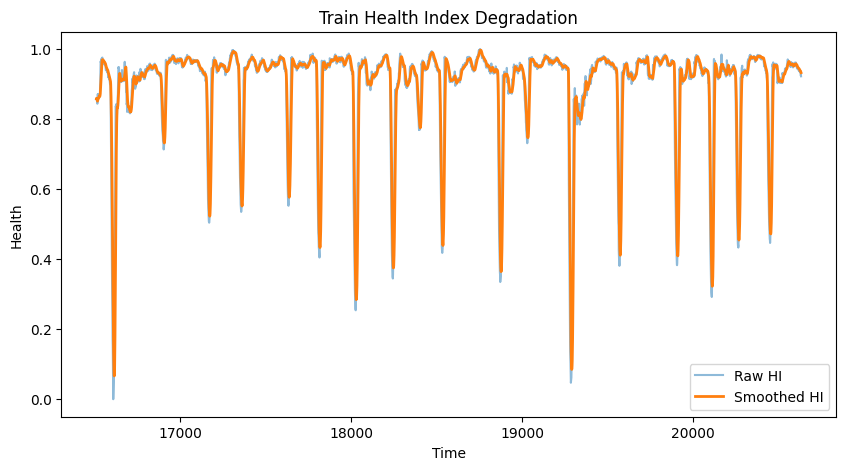

In [46]:
# STEP 13: VISUALIZATION
plt.figure(figsize=(10,5))

plt.plot(data["Health_Index"], label="Raw HI", alpha=0.5)
plt.plot(data["Health_Index_Smoothed"], label="Smoothed HI", linewidth=2)

plt.xlabel("Time")
plt.ylabel("Health")
plt.title("Train Health Index Degradation")

plt.legend()
plt.show()

In [47]:

# # TRAINING 
# import pandas as pd
# import numpy as np
# from sklearn.preprocessing import MinMaxScaler
# from tensorflow.keras.models import Model
# from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
# from tensorflow.keras.optimizers import Adam


# # 1. LOAD TRAIN DATA
# train_data = pd.read_csv("train_FD001.txt", sep=" ", header=None)
# train_data.drop(columns=[26,27], inplace=True)

# columns = [
# 'unit_number','time_in_cycles','setting_1','setting_2','TRA','T2','T24','T30','T50',
# 'P2','P15','P30','Nf','Nc','epr','Ps30','phi','NRf','NRc','BPR','farB',
# 'htBleed','Nf_dmd','PCNfR_dmd','W31','W32'
# ]
# train_data.columns = columns


# # 2. PREPROCESSING
# train_data = train_data.ffill()

# train_data.drop(columns=[
# 'Nf_dmd','PCNfR_dmd','P2','T2','TRA','farB','epr'
# ], inplace=True)


# # 3. NORMALIZATION (FIT SCALER HERE)
# sensor_train = train_data.drop(columns=['unit_number','time_in_cycles'])

# scaler = MinMaxScaler()
# sensor_train_scaled = scaler.fit_transform(sensor_train)

# sensor_train_scaled = pd.DataFrame(sensor_train_scaled, columns=sensor_train.columns)


# # 4. CREATE SEQUENCES
# def create_sequences(data, seq_length):
#     sequences = []
#     for i in range(len(data) - seq_length):
#         sequences.append(data.iloc[i:i+seq_length].values)
#     return np.array(sequences)

# sequence_length = 30
# X_sequences = create_sequences(sensor_train_scaled, sequence_length)


# # 5. TRAIN-VALIDATION SPLIT
# split = int(0.8 * len(X_sequences))
# X_train = X_sequences[:split]
# X_val = X_sequences[split:]


# # 6. BUILD MODEL
# timesteps = X_train.shape[1]
# features = X_train.shape[2]

# input_layer = Input(shape=(timesteps, features))

# encoded = LSTM(64, activation='relu', return_sequences=False)(input_layer)
# latent = RepeatVector(timesteps)(encoded)
# decoded = LSTM(64, activation='relu', return_sequences=True)(latent)
# output_layer = TimeDistributed(Dense(features))(decoded)

# model = Model(inputs=input_layer, outputs=output_layer)
# model.compile(optimizer=Adam(0.001), loss='mse')


# # 7. TRAIN MODEL
# model.fit(
#     X_train, X_train,
#     epochs=5,
#     batch_size=64,
#     validation_data=(X_val, X_val),
#     shuffle=False
# )


# # 8. GET ERROR RANGE (IMPORTANT)
# X_val_pred = model.predict(X_val)

# reconstruction_error_train = np.mean(
#     np.power(X_val - X_val_pred, 2),
#     axis=(1,2)
# )

# # store these for test use
# error_min = reconstruction_error_train.min()
# error_max = reconstruction_error_train.max()

## Test_Data

In [48]:
# STEP 1: LOAD TEST DATA

test_data = pd.read_csv(
    r"C:\Users\Chekk\OneDrive\Desktop\Major_Project\Machine_Learning_Project\test_FD001.txt",
    sep=" ",
    header=None
)

test_data.drop(columns=[26, 27], inplace=True)

columns = [
    'unit_number','time_in_cycles','setting_1','setting_2','TRA','T2','T24','T30','T50',
    'P2','P15','P30','Nf','Nc','epr','Ps30','phi','NRf','NRc','BPR','farB',
    'htBleed','Nf_dmd','PCNfR_dmd','W31','W32'
]

test_data.columns = columns

In [49]:
# Handle missing values
test_data = test_data.ffill()

# Drop same columns (IMPORTANT consistency)
test_data.drop(columns=[
    'Nf_dmd','PCNfR_dmd','P2','T2','TRA','farB','epr'
], inplace=True)

In [50]:
sensor_test = test_data.drop(columns=['unit_number','time_in_cycles'])

sensor_test_scaled = scaler.transform(sensor_test)

sensor_test_scaled = pd.DataFrame(sensor_test_scaled, columns=sensor_test.columns)


In [51]:
scaler.fit_transform(test_data)

array([[0.        , 0.        , 0.65625   , ..., 0.375     , 0.5       ,
        0.62009908],
       [0.        , 0.00331126, 0.34375   , ..., 0.5       , 0.64545455,
        0.64571833],
       [0.        , 0.00662252, 0.53125   , ..., 0.5       , 0.7       ,
        0.68110403],
       ...,
       [1.        , 0.64569536, 0.475     , ..., 0.75      , 0.28181818,
        0.38174098],
       [1.        , 0.64900662, 0.275     , ..., 0.75      , 0.31818182,
        0.47346072],
       [1.        , 0.65231788, 0.59375   , ..., 0.875     , 0.35454545,
        0.35399858]], shape=(13096, 19))

In [52]:
def create_sequences(data, seq_length):
    sequences = []
    for i in range(len(data) - seq_length):
        sequences.append(data.iloc[i:i+seq_length].values)
    return np.array(sequences)

sequence_length = 30

X_test_seq = create_sequences(sensor_test_scaled, sequence_length)

print("Test Shape:", X_test_seq.shape)

Test Shape: (13066, 30, 17)


In [53]:
X_test_pred = model.predict(X_test_seq)

409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


In [54]:
reconstruction_error_test = np.mean(
    np.power(X_test_seq - X_test_pred, 2),
    axis=(1,2)
)

In [55]:
health_index_test = 1 - (
    (reconstruction_error_test - error_min) /
    (error_max - error_min)
)

health_index_test = np.clip(health_index_test, 0, 1)

health_index_test_smooth = pd.Series(health_index_test).rolling(
    window=10, min_periods=1
).mean()

In [56]:
test_data["Health_Index"] = np.nan
test_data["Health_Index_Smoothed"] = np.nan

test_data.loc[
    sequence_length:sequence_length + len(health_index_test) - 1,
    "Health_Index"
] = health_index_test

test_data.loc[
    sequence_length:sequence_length + len(health_index_test_smooth) - 1,
    "Health_Index_Smoothed"
] = health_index_test_smooth.values

In [57]:
def health_condition(hi):
    if hi >= 0.8:
        return "GOOD"
    elif hi >= 0.5:
        return "MODERATE"
    else:
        return "BAD"

test_data["Condition"] = test_data["Health_Index"].apply(
    lambda x: health_condition(x) if pd.notnull(x) else np.nan
)

In [58]:
status = "GOOD"   # change to GOOD / MODERATE / BAD

filtered_test = test_data[test_data["Condition"] == status]

print(filtered_test[[
    "unit_number",
    "time_in_cycles",
    "Health_Index",
    "Condition"
]].head(20))

    unit_number  time_in_cycles  Health_Index Condition
30            1              31      0.977903      GOOD
31            2               1      0.977321      GOOD
32            2               2      0.980327      GOOD
33            2               3      0.978524      GOOD
34            2               4      0.973319      GOOD
35            2               5      0.974226      GOOD
36            2               6      0.972031      GOOD
37            2               7      0.965988      GOOD
38            2               8      0.958003      GOOD
39            2               9      0.957124      GOOD
40            2              10      0.951834      GOOD
41            2              11      0.953717      GOOD
42            2              12      0.954354      GOOD
43            2              13      0.956160      GOOD
44            2              14      0.963431      GOOD
45            2              15      0.963174      GOOD
46            2              16      0.963098   

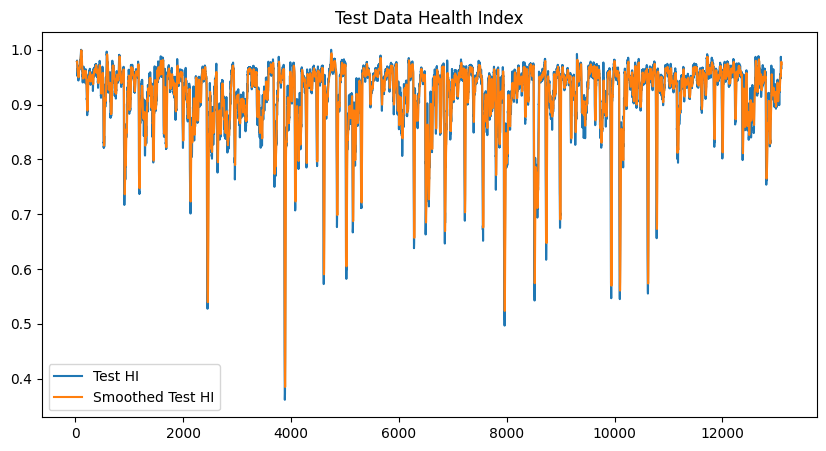

In [59]:
plt.figure(figsize=(10,5))

plt.plot(test_data["Health_Index"], label="Test HI")
plt.plot(test_data["Health_Index_Smoothed"], label="Smoothed Test HI")

plt.title("Test Data Health Index")
plt.legend()
plt.show()

In [60]:

# # TEST PART (EVALUATE MACHINE CONDITION)
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# # 1. LOAD TEST DATA
# test_data = pd.read_csv("test_FD001.txt", sep=" ", header=None)
# test_data.drop(columns=[26,27], inplace=True)
# test_data.columns = columns

# # 2. PREPROCESSING (SAME AS TRAIN)
# test_data = test_data.ffill()

# test_data.drop(columns=[
# 'Nf_dmd','PCNfR_dmd','P2','T2','TRA','farB','epr'
# ], inplace=True)
# # 
# # 3. NORMALIZATION (USE SAME SCALER)
# sensor_test = test_data.drop(columns=['unit_number','time_in_cycles'])

# sensor_test_scaled = scaler.transform(sensor_test)

# sensor_test_scaled = pd.DataFrame(sensor_test_scaled, columns=sensor_test.columns)

# # 4. CREATE SEQUENCES
# X_test_seq = create_sequences(sensor_test_scaled, sequence_length)

# # 5. PREDICT USING TRAINED MODEL
# X_test_pred = model.predict(X_test_seq)

# # 6. RECONSTRUCTION ERROR
# reconstruction_error_test = np.mean(
#     np.power(X_test_seq - X_test_pred, 2),
#     axis=(1,2)
# )


# # 7. HEALTH INDEX
# health_index_test = 1 - (
#     (reconstruction_error_test - error_min) /
#     (error_max - error_min)
# )



# health_index_test = np.clip(health_index_test, 0, 1)
# health_index_test_smooth = pd.Series(health_index_test).rolling(
# window=10, min_periods=1).mean()

# # 8. ADD TO DATASET
# test_data["Health_Index"] = np.nan
# test_data["Health_Index_Smoothed"] = np.nan

# test_data.loc[sequence_length:sequence_length + len(health_index_test) - 1,
#     "Health_Index"] = health_index_test

# test_data.loc[
#     sequence_length:sequence_length + len(health_index_test_smooth) - 1,
#     "Health_Index_Smoothed"] = health_index_test_smooth.values

# # 9. CONDITION CLASSIFICATION
# def health_condition(hi):
#     if hi >= 0.8:
#         return "GOOD"
#     elif hi >= 0.5:
#         return "MODERATE"
#     else:
#         return "BAD"

# test_data["Condition"] = test_data["Health_Index"].apply(
#     lambda x: health_condition(x) if pd.notnull(x) else np.nan)

# # 10. FILTER RESULTS
# status = "BAD"   # change to GOOD / MODERATE / BAD

# filtered_test = test_data[test_data["Condition"] == status]

# print(filtered_test[[ "unit_number","time_in_cycles","Health_Index",
#     "Condition"]].head(20))


# # 11. VISUALIZATION
# plt.figure(figsize=(10,5))

# plt.plot(test_data["Health_Index"], label="Test HI")
# plt.plot(test_data["Health_Index_Smoothed"], label="Smoothed HI")

# plt.title("Test Data Health Index")
# plt.legend()
# plt.show()